In [1]:
import os
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

from langchain.chat_models import init_chat_model

llm=init_chat_model("openai:gpt-4o-mini")
llm_ollama = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

langfuse_trace = CallbackHandler()

d:\ai_learning\krisknaik\ultimate-rag-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Cache variable
Model_Cache={}

import time

def cache_model(query):
    start_time=time.time()
    if Model_Cache.get(query):
        print("**CAche Hit**")
        end_time=time.time()
        elapsed_time=end_time-start_time
        print(f"EXECUTION TIME: {elapsed_time:.2f} seconds")
        return Model_Cache.get(query)
    else:
        print("***CACHE MISS – EXECUTING MODEL***")
        start_time = time.time()
        response = llm_ollama.invoke(query)
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"EXECUTION TIME: {elapsed:.2f} seconds")
        Model_Cache[query] = response
        return response


In [3]:
response=cache_model("hi")
response

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 27.47 seconds


AIMessage(content='Hello! How can I help you today? If you have any questions or need assistance, feel free to ask.', additional_kwargs={}, response_metadata={'model': 'granite4', 'created_at': '2026-06-30T07:14:14.33060189Z', 'done': True, 'done_reason': 'stop', 'total_duration': 27461294489, 'load_duration': 25313353332, 'prompt_eval_count': 9, 'prompt_eval_duration': 199349000, 'eval_count': 24, 'eval_duration': 1945331000, 'logprobs': None, 'model_name': 'granite4', 'model_provider': 'ollama'}, id='lc_run--019f1760-7b72-7e62-a1b2-5e8e50e15ec7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 24, 'total_tokens': 33})

In [4]:
Model_Cache

response=cache_model("hi")
response

**CAche Hit**
EXECUTION TIME: 0.00 seconds


AIMessage(content='Hello! How can I help you today? If you have any questions or need assistance, feel free to ask.', additional_kwargs={}, response_metadata={'model': 'granite4', 'created_at': '2026-06-30T07:14:14.33060189Z', 'done': True, 'done_reason': 'stop', 'total_duration': 27461294489, 'load_duration': 25313353332, 'prompt_eval_count': 9, 'prompt_eval_duration': 199349000, 'eval_count': 24, 'eval_duration': 1945331000, 'logprobs': None, 'model_name': 'granite4', 'model_provider': 'ollama'}, id='lc_run--019f1760-7b72-7e62-a1b2-5e8e50e15ec7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 24, 'total_tokens': 33})

In [5]:
query="can you give me 500 words on langgraph?"
response =cache_model(query)
print(response)

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 67.10 seconds
content="Langgraph is a powerful tool that has revolutionized the way we interact with and process natural language data. It is an advanced language processing system that combines various techniques from artificial intelligence, machine learning, and computational linguistics to analyze, understand, and generate human-like text.\n\nOne of the key aspects of Langgraph is its ability to perform complex linguistic analyses on vast amounts of textual data. It can identify patterns, extract meaningful information, and even predict future trends based on historical language usage. This makes it an invaluable resource for businesses, researchers, and organizations that rely heavily on text-based data analysis.\n\nThe system works by breaking down the input text into smaller units called tokens, which are then processed using various algorithms to determine their meaning and context. These tokens can be words, phrases, or even i

In [6]:
query="can you give me 500 words on langgraph?"
response =cache_model(query)
print(response)

**CAche Hit**
EXECUTION TIME: 0.00 seconds
content="Langgraph is a powerful tool that has revolutionized the way we interact with and process natural language data. It is an advanced language processing system that combines various techniques from artificial intelligence, machine learning, and computational linguistics to analyze, understand, and generate human-like text.\n\nOne of the key aspects of Langgraph is its ability to perform complex linguistic analyses on vast amounts of textual data. It can identify patterns, extract meaningful information, and even predict future trends based on historical language usage. This makes it an invaluable resource for businesses, researchers, and organizations that rely heavily on text-based data analysis.\n\nThe system works by breaking down the input text into smaller units called tokens, which are then processed using various algorithms to determine their meaning and context. These tokens can be words, phrases, or even individual characters, 

In [7]:
query="give me 500 words on langgraph?"
response =cache_model(query)
print(response)

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 75.94 seconds
content='Langgraph, also known as Language Graph or Linguistic Graph, is a powerful tool used in the field of natural language processing (NLP) and computational linguistics. It represents a graphical structure that captures the relationships between different linguistic elements within a given text or corpus. This graph-based approach provides a comprehensive way to analyze and understand the underlying patterns and structures of human languages.\n\nAt its core, a Langgraph is composed of nodes and edges. The nodes represent various linguistic units such as words, phrases, sentences, clauses, or even higher-level syntactic structures like noun phrases, verb phrases, or entire sentences. These nodes are interconnected by directed edges that depict the relationships between them, such as grammatical dependencies, semantic connections, or discourse links.\n\nOne of the key advantages of using a Langgraph is its ability to c

### Advanced CAG

In [8]:
from __future__ import annotations
from typing import TypedDict, List, Optional
import time

# ---- LangGraph / LangChain ----
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings

# ---- FAISS vector stores ----
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_24088\2640311738.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [9]:
# ================= CONFIG =================
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # 384-dim
VECTOR_DIM = 384

LLM_MODEL = "gpt-4o-mini"
LLM_TEMPERATURE = 0

RETRIEVE_TOP_K = 4
CACHE_TOP_K = 3

CACHE_DISTANCE_THRESHOLD = 0.45

# Optional TTL for cache entries (seconds). 0 = disabled.
CACHE_TTL_SEC = 0

In [10]:
# ================= STATE ==================

class RAGState(TypedDict):
    question: str
    normalized_question: str
    context_docs: List[Document]
    answer: Optional[str]
    citations: List[str]
    cache_hit: bool

In [11]:
from langchain_community.embeddings import HuggingFaceEmbeddings

EMBED = HuggingFaceEmbeddings(model_name=EMBED_MODEL)  

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_24088\3445923316.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  EMBED = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8452.62it/s]


In [12]:
# ----- QA CACHE (EMPTY, SAFE INIT) -----
qa_index = faiss.IndexFlatL2(VECTOR_DIM)  # distance; lower is better
QA_CACHE = FAISS(
    embedding_function=EMBED,
    index=qa_index,
    docstore=InMemoryDocstore({}),
    index_to_docstore_id={}
)

In [13]:
QA_CACHE

In [14]:
# ----- RAG STORE (demo only) -----
RAG_STORE = FAISS.from_texts(
    texts=[
        "LangGraph lets you compose stateful LLM workflows as graphs.",
        "In LangGraph, nodes can be cached; node caching memoizes outputs keyed by inputs for a TTL.",
        "Retrieval-Augmented Generation (RAG) retrieves external context and injects it into prompts.",
        "Semantic caching reuses prior answers when new questions are semantically similar."
    ],
    embedding=EMBED,
)

In [15]:
RAG_STORE

In [16]:
# ================ NODES ===================

def normalize_query(state: RAGState) -> RAGState:
    q = (state["question"] or "").strip()
    state["normalized_question"] = q.lower()
    return state

def semantic_cache_lookup(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    state["cache_hit"] = False  # default

    if not q:
        return state

    # ✅ Guard: FAISS crashes if ntotal == 0 and you ask for k>0
    if getattr(QA_CACHE, "index", None) is None or QA_CACHE.index.ntotal == 0:
        return state

    # For FAISS L2 wrapper, this returns (Document, distance) with lower=better
    hits = QA_CACHE.similarity_search_with_score(q, k=CACHE_TOP_K)
    if not hits:
        return state

    best_doc, dist = hits[0]

    # Optional TTL
    if CACHE_TTL_SEC > 0:
        ts = best_doc.metadata.get("ts")
        if ts is None or (time.time() - float(ts)) > CACHE_TTL_SEC:
            return state

    # L2 distance gate (lower = more similar)
    if dist <= CACHE_DISTANCE_THRESHOLD:
        cached_answer = best_doc.metadata.get("answer")
        if cached_answer:
            state["answer"] = cached_answer
            state["citations"] = ["(cache)"]
            state["cache_hit"] = True

    return state

def respond_from_cache(state: RAGState) -> RAGState:
    return state

def retrieve(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    docs = RAG_STORE.similarity_search(q, k=RETRIEVE_TOP_K)
    state["context_docs"] = docs
    return state

def generate(state: RAGState) -> RAGState:
    q = state["question"]
    docs = state.get("context_docs", [])
    ctx = "\n\n".join([f"[doc-{i}] {d.page_content}" for i, d in enumerate(docs, start=1)])

    system = (
        "You are a precise RAG assistant. Use the context when helpful. "
        "Cite with [doc-i] markers if you use a fact from the context."
    )
    user = f"Question: {q}\n\nContext:\n{ctx}\n\nWrite a concise answer with citations."

    resp = llm_ollama.invoke(
        [{"role": "system", "content": system},
                       {"role": "user", "content": user}],
        config={"callbacks": [langfuse_trace]}
    )
    state["answer"] = resp.content
    state["citations"] = [f"[doc-{i}]" for i in range(1, len(docs) + 1)]
    return state

def cache_write(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    a = state.get("answer")
    if not q or not a:
        return state

    QA_CACHE.add_texts(
        texts=[q],
        metadatas=[{
            "answer": a,
            "ts": time.time(),
        }]
    )
    return state

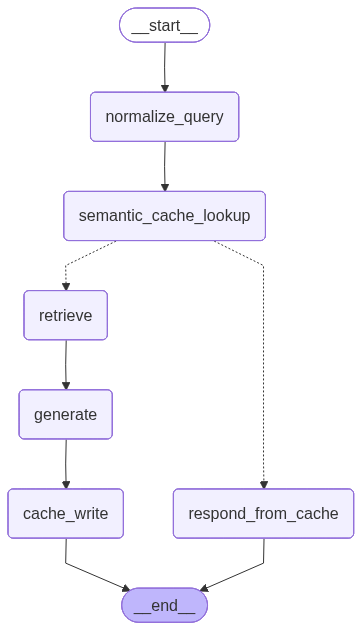

In [17]:
# ============== GRAPH WIRING ==============
graph = StateGraph(RAGState)

graph.add_node("normalize_query", normalize_query)
graph.add_node("semantic_cache_lookup", semantic_cache_lookup)
graph.add_node("respond_from_cache", respond_from_cache)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_node("cache_write", cache_write)

graph.set_entry_point("normalize_query")
graph.add_edge("normalize_query", "semantic_cache_lookup")

def _branch(state: RAGState) -> str:
    return "respond_from_cache" if state.get("cache_hit") else "retrieve"

graph.add_conditional_edges(
    "semantic_cache_lookup",
    _branch,
    {
        "respond_from_cache": "respond_from_cache",
        "retrieve": "retrieve"
    }
)

graph.add_edge("respond_from_cache", END)
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "cache_write")
graph.add_edge("cache_write", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)
app

In [18]:
# ================= DEMO ===================
if __name__ == "__main__":
    thread_cfg = {"configurable": {"thread_id": "demo-user-1"}, "callbacks": [langfuse_trace]}

    q1 = "What is LangGraph ?"
    out1 = app.invoke(
        {"question": q1, "context_docs": [], "citations": []}, thread_cfg
    )
    print("Answer:", out1["answer"])
    print("Citations:", out1.get("citations"))
    print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph is an architecture that allows for the composition of stateful LLM workflows as graphs, enabling node caching where outputs can be memoized based on inputs for a specified TTL [doc-1]. It also supports Retrieval-Augmented Generation (RAG), which retrieves external context and injects it into prompts [doc-3], and semantic caching that reuses prior answers when new questions are semantically similar [doc-4].
[Citation needed]
Citations: ['[doc-1]', '[doc-2]', '[doc-3]', '[doc-4]']
Cache hit?: False


In [19]:
q1 = "Explain about LangGraph ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph is an architecture that allows for the composition of stateful LLM workflows as graphs, enabling node caching where outputs can be memoized based on inputs for a specified TTL [doc-1]. It also supports Retrieval-Augmented Generation (RAG), which retrieves external context and injects it into prompts [doc-3], and semantic caching that reuses prior answers when new questions are semantically similar [doc-4].
[Citation needed]
Citations: ['(cache)']
Cache hit?: True


In [20]:
q1 = "Explain about LangGraph agents ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph agents allow for the composition of stateful LLM workflows as graphs [doc-2]. This enables complex interactions between nodes, where outputs can be cached and reused [doc-1]. Additionally, LangGraph supports Retrieval-Augmented Generation (RAG), which retrieves relevant external context to inject into prompts, enhancing the generality of the generated responses [doc-3]. Semantic caching further refines this process by reusing prior answers when new questions are semantically similar, improving efficiency and reducing redundant computations [doc-4].
Cited Documents: [doc-1][doc-2][doc-3][doc-4]
Citations: ['[doc-1]', '[doc-2]', '[doc-3]', '[doc-4]']
Cache hit?: False


In [21]:
q1 = "Explain about agents in Langgraph ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph agents allow for the composition of stateful LLM workflows as graphs [doc-2]. This enables complex interactions between nodes, where outputs can be cached and reused [doc-1]. Additionally, LangGraph supports Retrieval-Augmented Generation (RAG), which retrieves relevant external context to inject into prompts, enhancing the generality of the generated responses [doc-3]. Semantic caching further refines this process by reusing prior answers when new questions are semantically similar, improving efficiency and reducing redundant computations [doc-4].
Cited Documents: [doc-1][doc-2][doc-3][doc-4]
Citations: ['(cache)']
Cache hit?: True
